# BPE Tokenizer Analysis: Deep Dive

This notebook provides a comprehensive analysis of our custom BPE (Byte Pair Encoding) tokenizer implementation for Neural Machine Translation.

In [4]:
import sys
sys.path.insert(0, '..')

from src.data.bpe_tokenizer import BPETokenizer
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load and Inspect Tokenizer

In [5]:
tokenizer = BPETokenizer.load('../data/vocab/bpe_vocab_shared.pkl')
print(f"Tokenizer loaded!")
print()
print("Configuration:")
print(f"  Vocab size (configured): {tokenizer.vocab_size:,}")
print(f"  Min frequency:           {tokenizer.min_freq}")
print()
print("Learned statistics:")
print(f"  Actual vocab size:       {len(tokenizer.token2idx):,}")
print(f"  Merge operations:        {len(tokenizer.merges):,}")
print(f"  Special tokens:          {tokenizer.special_tokens}")

Tokenizer loaded!

Configuration:
  Vocab size (configured): 32,000
  Min frequency:           2

Learned statistics:
  Actual vocab size:       31,992
  Merge operations:        30,866
  Special tokens:          ['<PAD>', '<UNK>', '<BOS>', '<EOS>']


## 2. Vocabulary Analysis

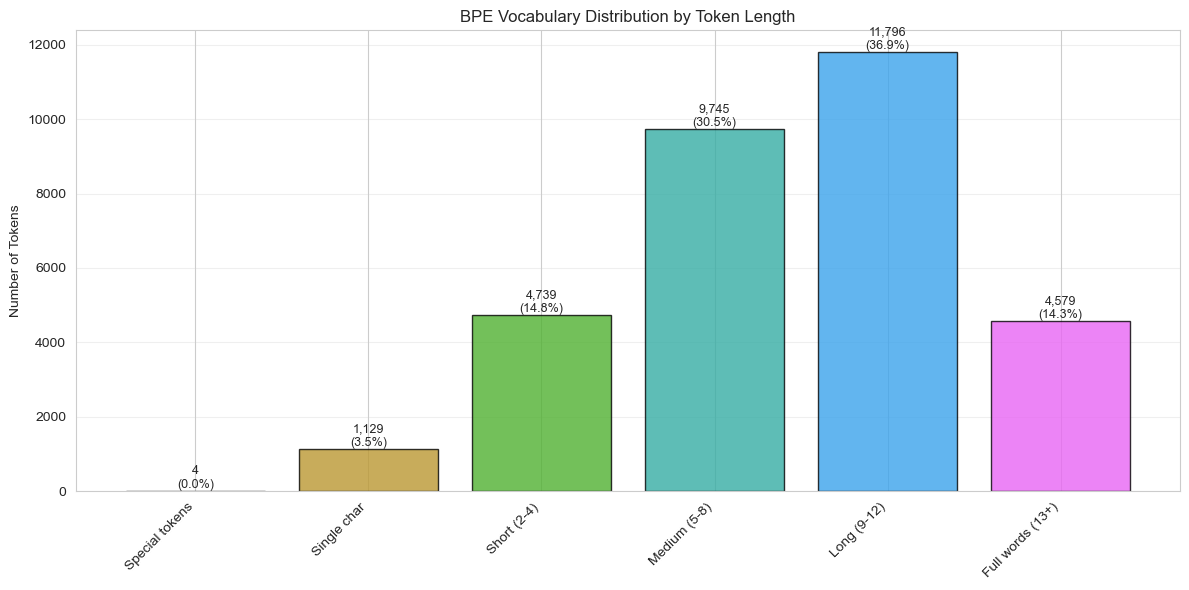

In [6]:
def analyze_vocab(tokenizer):
    special = []
    single_char = []
    short_subwords = []  # 2-4 chars
    medium_subwords = [] # 5-8 chars
    long_subwords = []   # 9-12 chars
    full_words = []      # 13+ chars
    
    for token in tokenizer.token2idx.keys():
        if token in tokenizer.special_tokens:
            special.append(token)
        elif len(token) == 1:
            single_char.append(token)
        elif 2 <= len(token) <= 4:
            short_subwords.append(token)
        elif 5 <= len(token) <= 8:
            medium_subwords.append(token)
        elif 9 <= len(token) <= 12:
            long_subwords.append(token)
        else:
            full_words.append(token)
    
    return {
        'Special tokens': special,
        'Single char': single_char,
        'Short (2-4)': short_subwords,
        'Medium (5-8)': medium_subwords,
        'Long (9-12)': long_subwords,
        'Full words (13+)': full_words,
    }

vocab_categories = analyze_vocab(tokenizer)

categories = list(vocab_categories.keys())
counts = [len(tokens) for tokens in vocab_categories.values()]
total = sum(counts)

plt.figure(figsize=(12, 6))
colors = sns.color_palette('husl', len(categories))
plt.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black')
plt.ylabel('Number of Tokens')
plt.title('BPE Vocabulary Distribution by Token Length')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for i, (cat, count) in enumerate(zip(categories, counts)):
    plt.text(i, count, f'{count:,}\n({count/total*100:.1f}%)', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# Sample tokens from each category
print("\nSample Tokens from Each Category:")
print("="*70)

for category, tokens in vocab_categories.items():
    if category == 'Special tokens':
        print(f"\n{category}:")
        print(f"  {tokens}")
    else:
        # Show 15 random samples
        samples = np.random.choice(tokens, min(15, len(tokens)), replace=False)
        print(f"\n{category} (showing {len(samples)} of {len(tokens)}):")
        print(f"  {list(samples)}")


Sample Tokens from Each Category:

Special tokens:
  ['<PAD>', '<UNK>', '<BOS>', '<EOS>']

Single char (showing 15 of 1129):
  [np.str_('し'), np.str_('ﺴ'), np.str_('ذ'), np.str_('投'), np.str_('ϋ'), np.str_('ų'), np.str_('ē'), np.str_('ع'), np.str_('北'), np.str_('ⴗ'), np.str_('ラ'), np.str_('λ'), np.str_('长'), np.str_('►'), np.str_('多')]

Short (2-4) (showing 15 of 4739):
  [np.str_('lav'), np.str_('ho'), np.str_('tele'), np.str_('médi'), np.str_('comb'), np.str_('cand'), np.str_('col'), np.str_('plic'), np.str_('ano'), np.str_('sett'), np.str_('édi'), np.str_('ví'), np.str_('afec'), np.str_('cl'), np.str_('ocur')]

Medium (5-8) (showing 15 of 9745):
  [np.str_('ego</w>'), np.str_('tea.</w>'), np.str_('m...</w>'), np.str_('fastidi'), np.str_('(oj</w>'), np.str_('previ'), np.str_('joe</w>'), np.str_('ken</w>'), np.str_('tic.</w>'), np.str_('xenopho'), np.str_('ins.</w>'), np.str_('espos'), np.str_('rehen'), np.str_('ado!</w>'), np.str_('a’s</w>')]

Long (9-12) (showing 15 of 11796):
  [n

## 3. Merge Operations Deep Dive

In [8]:
print("Merge Operations Analysis:")
print("="*70)
print(f"Total merges learned: {len(tokenizer.merges):,}")
print()

# Show first 20 merges
print("First 20 merges (highest frequency):")
print("-"*70)
for i, ((t1, t2), merged) in enumerate(tokenizer.merges[:20], 1):
    print(f"  {i:2d}. ({t1!r:6s}, {t2!r:6s}) → {merged!r}")

Merge Operations Analysis:
Total merges learned: 30,866

First 20 merges (highest frequency):
----------------------------------------------------------------------
   1. ('e'   , '</w>') → 'e</w>'
   2. ('s'   , '</w>') → 's</w>'
   3. ('a'   , '</w>') → 'a</w>'
   4. ('o'   , '</w>') → 'o</w>'
   5. ('n'   , '</w>') → 'n</w>'
   6. ('e'   , 'r'   ) → 'er'
   7. ('.'   , '</w>') → '.</w>'
   8. ('t'   , 'h'   ) → 'th'
   9. (','   , '</w>') → ',</w>'
  10. ('e'   , 'n'   ) → 'en'
  11. ('a'   , 'r'   ) → 'ar'
  12. ('e'   , 's'   ) → 'es'
  13. ('i'   , 'n'   ) → 'in'
  14. ('a'   , 'n'   ) → 'an'
  15. ('t'   , '</w>') → 't</w>'
  16. ('o'   , 'r'   ) → 'or'
  17. ('l'   , '</w>') → 'l</w>'
  18. ('o'   , 'n'   ) → 'on'
  19. ('d'   , '</w>') → 'd</w>'
  20. ('y'   , '</w>') → 'y</w>'


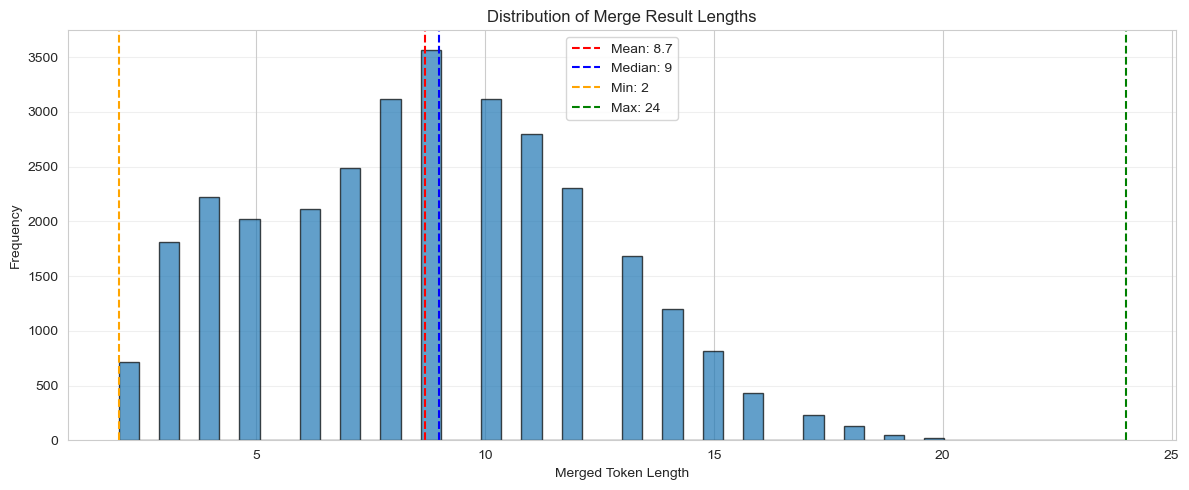

In [9]:
# Analyze merge characteristics
merge_lengths = []
for (t1, t2), merged in tokenizer.merges:
    merge_lengths.append(len(merged))

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)
plt.hist(merge_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Merged Token Length')
plt.ylabel('Frequency')
plt.title('Distribution of Merge Result Lengths')
plt.axvline(np.mean(merge_lengths), color='red', linestyle='--', 
            label=f'Mean: {np.mean(merge_lengths):.1f}')
plt.axvline(np.median(merge_lengths), color='blue', linestyle='--', 
            label=f'Median: {np.median(merge_lengths):.0f}')
plt.axvline(min(merge_lengths), color='orange', linestyle='--', 
            label=f'Min: {min(merge_lengths)}')
plt.axvline(max(merge_lengths), color='green', linestyle='--', 
            label=f'Max: {max(merge_lengths)}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Encoding Mechanism

In [10]:
def detailed_encode_trace(tokenizer, text):
    """Trace the encoding process step by step."""
    print(f"Input text: {text!r}")
    print()
    
    # Step 1: Preprocessing
    preprocessed = tokenizer._preprocess(text)
    print(f"After preprocessing: {preprocessed!r}")
    
    # Step 2: Split into words
    words = preprocessed.split()
    print(f"Split into words: {words}")
    print()
    
    # Step 3: Process each word
    all_indices = []
    for i, word in enumerate(words, 1):
        print(f"Word {i}: '{word}'")
        
        # Character-level
        chars = list(word) + [tokenizer.EOW_TOKEN]

        print(f"  Characters: {chars}")
        
        # Apply merges
        tokens = tokenizer._apply_merges(chars)
        print(f"  After BPE:  {tokens}")
        
        # Convert to indices
        indices = []
        for token in tokens:
            if token in tokenizer.token2idx:
                idx = tokenizer.token2idx[token]
                indices.append(idx)
            else:
                idx = tokenizer.token2idx[tokenizer.UNK_TOKEN]
                indices.append(idx)
        print(f"  Indices:    {indices}")
        all_indices.extend(indices)
        print()
    
    # Final result
    print(f"Final encoding: {all_indices}")
    
    # Decode to verify
    decoded = tokenizer.decode(all_indices)
    print(f"Decoded back:   {decoded!r}")
    print()
    

# Test with various examples
test_sentences = [
    "Hello world!",
    "The international community",
    "playing, walked, development",
]

for sentence in test_sentences:
    print("="*70)
    detailed_encode_trace(tokenizer, sentence)
    print()

Input text: 'Hello world!'

After preprocessing: 'hello world!'
Split into words: ['hello', 'world!']

Word 1: 'hello'
  Characters: ['h', 'e', 'l', 'l', 'o', '</w>']
  After BPE:  ['hello</w>']
  Indices:    [14276]

Word 2: 'world!'
  Characters: ['w', 'o', 'r', 'l', 'd', '!', '</w>']
  After BPE:  ['world', '!</w>']
  Indices:    [30079, 10]

Final encoding: [14276, 30079, 10]
Decoded back:   'hello world!'


Input text: 'The international community'

After preprocessing: 'the international community'
Split into words: ['the', 'international', 'community']

Word 1: 'the'
  Characters: ['t', 'h', 'e', '</w>']
  After BPE:  ['the</w>']
  Indices:    [27527]

Word 2: 'international'
  Characters: ['i', 'n', 't', 'e', 'r', 'n', 'a', 't', 'i', 'o', 'n', 'a', 'l', '</w>']
  After BPE:  ['international</w>']
  Indices:    [15764]

Word 3: 'community'
  Characters: ['c', 'o', 'm', 'm', 'u', 'n', 'i', 't', 'y', '</w>']
  After BPE:  ['community</w>']
  Indices:    [6768]

Final encoding: [27

## 5. Morphological Analysis

In [11]:
# Check for common morphemes
english_morphemes = {
    'Prefixes': ['un', 're', 'in', 'dis', 'pre', 'post', 'anti', 'inter'],
    'Suffixes': ['ing', 'ed', 'ly', 'tion', 'ness', 'ment', 'able', 'ful', 'less'],
    'Roots': ['play', 'work', 'develop', 'nation', 'inform', 'establish'],
}

spanish_morphemes = {
    'Prefijos': ['des', 'in', 're', 'pre', 'anti', 'inter'],
    'Sufijos': ['ción', 'mente', 'dad', 'ismo', 'ista', 'ador', 'able'],
    'Raíces': ['nación', 'desarrollo', 'información', 'trabajo'],
}

def check_morphemes(tokenizer, morpheme_dict, language):
    print(f"\n{language} Morphological Coverage:")
    print("="*70)
    
    for category, morphemes in morpheme_dict.items():
        print(f"\n{category}:")
        found = []
        missing = []
        
        for m in morphemes:
            exists = (m in tokenizer.token2idx or 
                         f"{m}</w>" in tokenizer.token2idx)
            
            if exists:
                found.append(m)
            else:
                missing.append(m)
        
        print(f"  Found ({len(found)}/{len(morphemes)}): {found}")
        if missing:
            print(f"  Missing: {missing}")

check_morphemes(tokenizer, english_morphemes, "English")
check_morphemes(tokenizer, spanish_morphemes, "Spanish")


English Morphological Coverage:

Prefixes:
  Found (8/8): ['un', 're', 'in', 'dis', 'pre', 'post', 'anti', 'inter']

Suffixes:
  Found (9/9): ['ing', 'ed', 'ly', 'tion', 'ness', 'ment', 'able', 'ful', 'less']

Roots:
  Found (6/6): ['play', 'work', 'develop', 'nation', 'inform', 'establish']

Spanish Morphological Coverage:

Prefijos:
  Found (6/6): ['des', 'in', 're', 'pre', 'anti', 'inter']

Sufijos:
  Found (7/7): ['ción', 'mente', 'dad', 'ismo', 'ista', 'ador', 'able']

Raíces:
  Found (4/4): ['nación', 'desarrollo', 'información', 'trabajo']


In [12]:
# Test morphological consistency
word_families = [
    ['play', 'playing', 'played', 'player', 'players'],
    ['develop', 'developing', 'developed', 'developer', 'development'],
    ['nation', 'national', 'international', 'nationality', 'nationalize'],
    ['inform', 'information', 'informed', 'informative', 'informant'],
]

print("\nMorphological Consistency Test:")
print("="*70)

for family in word_families:
    print(f"\nFamily: {family[0]}*")
    print("-"*70)
    
    for word in family:
        indices = tokenizer.encode(word)
        tokens = [tokenizer.idx2token[idx] for idx in indices]
        print(f"  {word:20s} → {tokens}")
    
    # Check for shared subwords
    all_tokenizations = [
        [tokenizer.idx2token[idx] for idx in tokenizer.encode(word)]
        for word in family
    ]
    
    # Find common tokens
    if all_tokenizations:
        common = set(all_tokenizations[0])
        for tokenization in all_tokenizations[1:]:
            common = common.intersection(set(tokenization))
        
        if common:
            print(f"  Common subwords: {list(common)}")


Morphological Consistency Test:

Family: play*
----------------------------------------------------------------------
  play                 → ['play</w>']
  playing              → ['playing</w>']
  played               → ['played</w>']
  player               → ['player</w>']
  players              → ['players</w>']

Family: develop*
----------------------------------------------------------------------
  develop              → ['develop</w>']
  developing           → ['developing</w>']
  developed            → ['developed</w>']
  developer            → ['develop', 'er</w>']
  development          → ['development</w>']

Family: nation*
----------------------------------------------------------------------
  nation               → ['nation</w>']
  national             → ['national</w>']
  international        → ['international</w>']
  nationality          → ['nationality</w>']
  nationalize          → ['nation', 'alize</w>']

Family: inform*
--------------------------------------------

## Bilingual Coverage

In [13]:
# Load sample data
def load_sample_data(file_path, n_samples=1000):
    """Load first n_samples from file."""
    with open(file_path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f.readlines()[:n_samples]]

# Load dev sets
dev_en = load_sample_data('../data/processed/opus-100/dev.en')
dev_es = load_sample_data('../data/processed/opus-100/dev.es')

In [14]:
# Analyze tokenization for both languages
def analyze_language_coverage(tokenizer, sentences, language):
    """Compute statistics for a language."""
    token_counts = []
    char_counts = []
    unk_counts = []
    
    for sent in sentences:
        if not sent:
            continue
        
        indices = tokenizer.encode(sent)
        token_counts.append(len(indices))
        char_counts.append(len(sent))
        
        # Count UNK tokens
        unk_count = sum(1 for idx in indices 
                       if tokenizer.idx2token[idx] == tokenizer.UNK_TOKEN)
        unk_counts.append(unk_count)
    
    return {
        'language': language,
        'avg_tokens': np.mean(token_counts),
        'avg_chars': np.mean(char_counts),
        'fertility': np.mean(token_counts) / np.mean(char_counts),
        'unk_rate': sum(unk_counts) / sum(token_counts) * 100,
        'token_counts': token_counts,
        'char_counts': char_counts,
    }

en_stats = analyze_language_coverage(tokenizer, dev_en, 'English')
es_stats = analyze_language_coverage(tokenizer, dev_es, 'Spanish')

# Display comparison
print("Bilingual Coverage Analysis:")
print("="*70)

print(f"English:  Avg Tokens/Sent={en_stats['avg_tokens']:.2f}  Avg Chars/Sent={en_stats['avg_chars']:.1f}  Fertility={en_stats['fertility']:.4f}  UNK Rate (%)={en_stats['unk_rate']:.3f}")
print(f"Spanish:  Avg Tokens/Sent={es_stats['avg_tokens']:.2f}  Avg Chars/Sent={es_stats['avg_chars']:.1f}  Fertility={es_stats['fertility']:.4f}  UNK Rate (%)={es_stats['unk_rate']:.3f}")

# ES/EN ratio (should be close to 1.0)
ratio = es_stats['avg_tokens'] / en_stats['avg_tokens']
print(f"\nES/EN token ratio: {ratio:.3f}")

Bilingual Coverage Analysis:
English:  Avg Tokens/Sent=15.88  Avg Chars/Sent=76.4  Fertility=0.2080  UNK Rate (%)=0.013
Spanish:  Avg Tokens/Sent=17.05  Avg Chars/Sent=82.2  Fertility=0.2074  UNK Rate (%)=0.012

ES/EN token ratio: 1.074


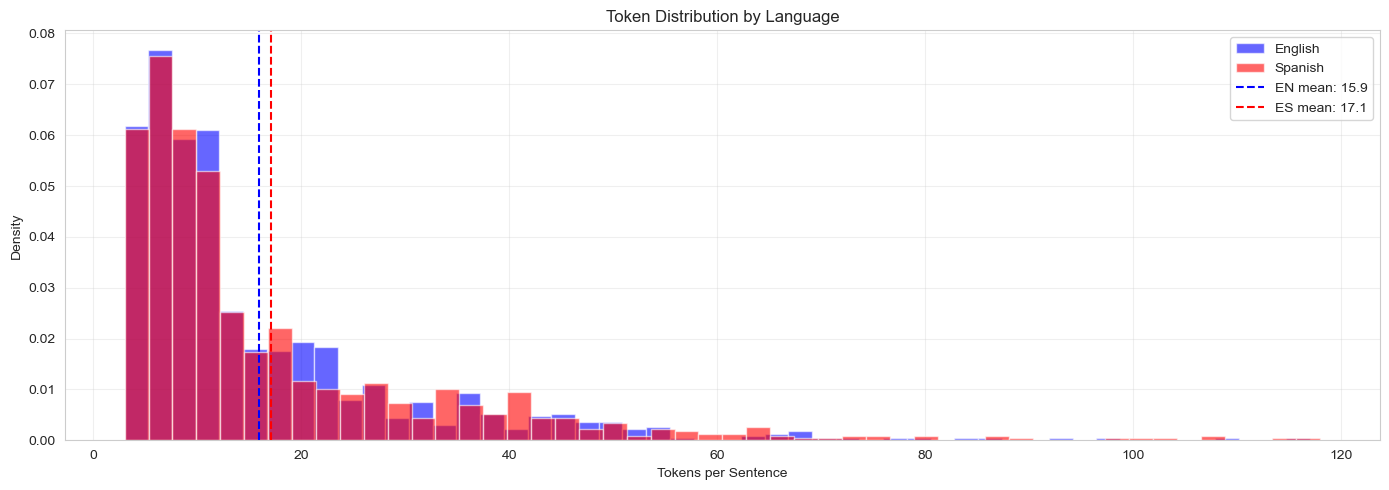

In [15]:
# Visualize distributions
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Token distribution
axes.hist(en_stats['token_counts'], bins=50, alpha=0.6, label='English', 
             color='blue', density=True)
axes.hist(es_stats['token_counts'], bins=50, alpha=0.6, label='Spanish', 
             color='red', density=True)
axes.axvline(en_stats['avg_tokens'], color='blue', linestyle='--', 
                label=f"EN mean: {en_stats['avg_tokens']:.1f}")
axes.axvline(es_stats['avg_tokens'], color='red', linestyle='--',
                label=f"ES mean: {es_stats['avg_tokens']:.1f}")
axes.set_xlabel('Tokens per Sentence')
axes.set_ylabel('Density')
axes.set_title('Token Distribution by Language')
axes.legend()
axes.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Quality Metrics

In [16]:
# Compression ratio
def compute_compression(tokenizer, sentences):
    """Compute compression metrics."""
    original_chars = sum(len(s) for s in sentences if s)
    total_tokens = sum(len(tokenizer.encode(s)) for s in sentences if s)
    
    return {
        'compression_ratio': original_chars / total_tokens,
        'avg_token_length': original_chars / total_tokens,
    }

en_compression = compute_compression(tokenizer, dev_en)
es_compression = compute_compression(tokenizer, dev_es)

print("Compression Metrics:")
print("="*70)
print(f"English:")
print(f"  Compression ratio: {en_compression['compression_ratio']:.2f} chars/token")
print(f"Spanish:")
print(f"  Compression ratio: {es_compression['compression_ratio']:.2f} chars/token")

Compression Metrics:
English:
  Compression ratio: 4.81 chars/token
Spanish:
  Compression ratio: 4.82 chars/token


In [17]:
# Vocabulary utilization
def measure_vocab_utilization(tokenizer, sentences):
    """Measure how much of the vocabulary is actually used."""
    used_tokens = set()
    
    for sent in sentences:
        if not sent:
            continue
        indices = tokenizer.encode(sent)
        used_tokens.update(indices)
    
    return len(used_tokens)

en_used = measure_vocab_utilization(tokenizer, dev_en)
es_used = measure_vocab_utilization(tokenizer, dev_es)
both_used = measure_vocab_utilization(tokenizer, dev_en + dev_es)

total_vocab = len(tokenizer.token2idx)

print("Vocabulary Utilization (on dev set):")
print("="*70)
print(f"Total vocabulary:     {total_vocab:6,}")
print(f"Used by EN:           {en_used:6,} ({en_used/total_vocab*100:5.2f}%)")
print(f"Used by ES:           {es_used:6,} ({es_used/total_vocab*100:5.2f}%)")
print(f"Used by both:         {both_used:6,} ({both_used/total_vocab*100:5.2f}%)")
print()
print(f"{both_used/total_vocab*100:.1f}% of vocab used on dev set")

Vocabulary Utilization (on dev set):
Total vocabulary:     31,992
Used by EN:            5,242 (16.39%)
Used by ES:            5,821 (18.20%)
Used by both:          9,684 (30.27%)

30.3% of vocab used on dev set


## Real Translation Examples

In [18]:
# Show parallel tokenization examples
print("Parallel Tokenization Examples:")
print("="*70)

for i in range(10):
    en_sent = dev_en[i]
    es_sent = dev_es[i]
    
    en_indices = tokenizer.encode(en_sent)
    es_indices = tokenizer.encode(es_sent)
    
    en_tokens = [tokenizer.idx2token[idx] for idx in en_indices]
    es_tokens = [tokenizer.idx2token[idx] for idx in es_indices]
    
    print(f"\nExample {i+1}:")
    print("-"*70)
    print(f"EN: {en_sent}")
    print(f"    {en_tokens}")
    print(f"    [{len(en_tokens)} tokens]")
    print()
    print(f"ES: {es_sent}")
    print(f"    {es_tokens}")
    print(f"    [{len(es_tokens)} tokens]")
    print(f"    Ratio: {len(es_tokens)/len(en_tokens):.2f}")

Parallel Tokenization Examples:

Example 1:
----------------------------------------------------------------------
EN: I don't even remember what the fight was about.
    ['i</w>', "don't</w>", 'even</w>', 'remember</w>', 'what</w>', 'the</w>', 'fight</w>', 'was</w>', 'about.</w>']
    [9 tokens]

ES: No recuerdo por qué fue la pelea.
    ['no</w>', 'recuerdo</w>', 'por</w>', 'qué</w>', 'fue</w>', 'la</w>', 'pele', 'a.</w>']
    [8 tokens]
    Ratio: 0.89

Example 2:
----------------------------------------------------------------------
EN: Here are the sites of each of those that have taken place:
    ['here</w>', 'are</w>', 'the</w>', 'sites</w>', 'of</w>', 'each</w>', 'of</w>', 'those</w>', 'that</w>', 'have</w>', 'taken</w>', 'plac', 'e:</w>']
    [13 tokens]

ES: Estos son los sitios en que cada Congreso ha tenido lugar:
    ['estos</w>', 'son</w>', 'los</w>', 'sitios</w>', 'en</w>', 'que</w>', 'cada</w>', 'congreso</w>', 'ha</w>', 'tenido</w>', 'lugar', ':</w>']
    [12 tokens]
 